In [ ]:
import sys, os

sys.path.insert(0, os.path.abspath('..'))
sys.path.insert(0, os.path.join(os.path.abspath('..'), 'config'))
from setup_env import setup

PROJECT_ROOT, DATA_DIR, DEVICE = setup()
print(f'PROJECT_ROOT = {PROJECT_ROOT}')
print(f'DATA_DIR     = {DATA_DIR}')
print(f'DEVICE       = {DEVICE}')


In [ ]:
import os, glob, random
from datetime import date
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

# Hyperparameters 
MODALITY    = 'mr_256'   # 'ct_256' or 'mr_256'
NUM_CLASSES = 8
BATCH_SIZE  = 20
LR          = 1e-4
EPOCHS      = 30
LOSS        = 'combined'  # 'combined' | 'dice' | 'ce'
EARLY_STOP_PATIENCE = 10
CLAHE_CLIP  = 0.3
CKPT_NAME   = f'best_resunet_mr_combined_loss_{date.today()}.pth'

#  Quick test mode 
QUICK_TEST      = False
MAX_TRAIN_FILES = 300 if QUICK_TEST else None
QUICK_EPOCHS    = 15  if QUICK_TEST else EPOCHS

CLASS_NAMES = {0:'BG', 1:'MYO', 2:'LA', 3:'LV', 4:'RA', 5:'RV', 6:'AA', 7:'PA'}

print(f'Device:     {DEVICE}')
print(f'Modality:   {MODALITY}')
print(f'Loss:       {LOSS}')
print(f'Epochs:     {QUICK_EPOCHS}')
print(f'Checkpoint: {CKPT_NAME}')

Device:     cuda
Modality:   mr_256
Loss:       combined
Epochs:     30
Checkpoint: best_resunet_mr_combined_loss_2026-03-31.pth


In [5]:
from src.dataset import apply_clahe, MMWHSDataset
from src.model   import build_model
from src.losses  import compute_weights, get_loss
from src.metrics import dice_binary, jaccard, surface_distances

In [6]:
#  Dataset
train_ds = MMWHSDataset(MODALITY, 'train', DATA_DIR, augment=True,  max_files=MAX_TRAIN_FILES, clahe_clip=CLAHE_CLIP)
val_ds   = MMWHSDataset(MODALITY, 'val',   DATA_DIR, augment=False, clahe_clip=CLAHE_CLIP)
test_ds  = MMWHSDataset(MODALITY, 'test',  DATA_DIR, augment=False, clahe_clip=CLAHE_CLIP)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=1,          shuffle=False, num_workers=0)

print(f'Train: {len(train_ds)}  Val: {len(val_ds)}  Test: {len(test_ds)}')

Train: 1738  Val: 254  Test: 236


In [7]:
#  Model 
model = build_model(NUM_CLASSES, DEVICE)

print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')
print(f'Encoder:    ResNet-34 (ImageNet pretrained)')
print(f'Attention:  scSE')
print(f'Seg head:   Dropout2d(p=0.15)')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Parameters: 24,545,103
Encoder:    ResNet-34 (ImageNet pretrained)
Attention:  scSE
Seg head:   Dropout2d(p=0.15)


In [8]:
#  Loss
print('Computing class weights...')
weights   = compute_weights(DATA_DIR, MODALITY, NUM_CLASSES, DEVICE)
criterion = get_loss(LOSS, weights, NUM_CLASSES)

print('Class weights:')
for i, w in enumerate(weights.cpu().numpy()):
    print(f'  {CLASS_NAMES[i]:<4}: {w:.4f}')

Computing class weights...
Class weights:
  BG  : 0.0093
  MYO : 0.7980
  LA  : 1.4052
  LV  : 0.7838
  RA  : 0.8178
  RV  : 0.6412
  AA  : 1.3867
  PA  : 2.1578


Epoch   1/30  train=1.4770  val=1.3621  lr=1.00e-04  patience=0
Epoch   2/30  train=1.2366  val=0.9975  lr=1.00e-04  patience=0
Epoch   3/30  train=0.9432  val=0.7872  lr=1.00e-04  patience=0
Epoch   4/30  train=0.7635  val=0.7070  lr=1.00e-04  patience=0
Epoch   5/30  train=0.6254  val=0.6215  lr=1.00e-04  patience=0


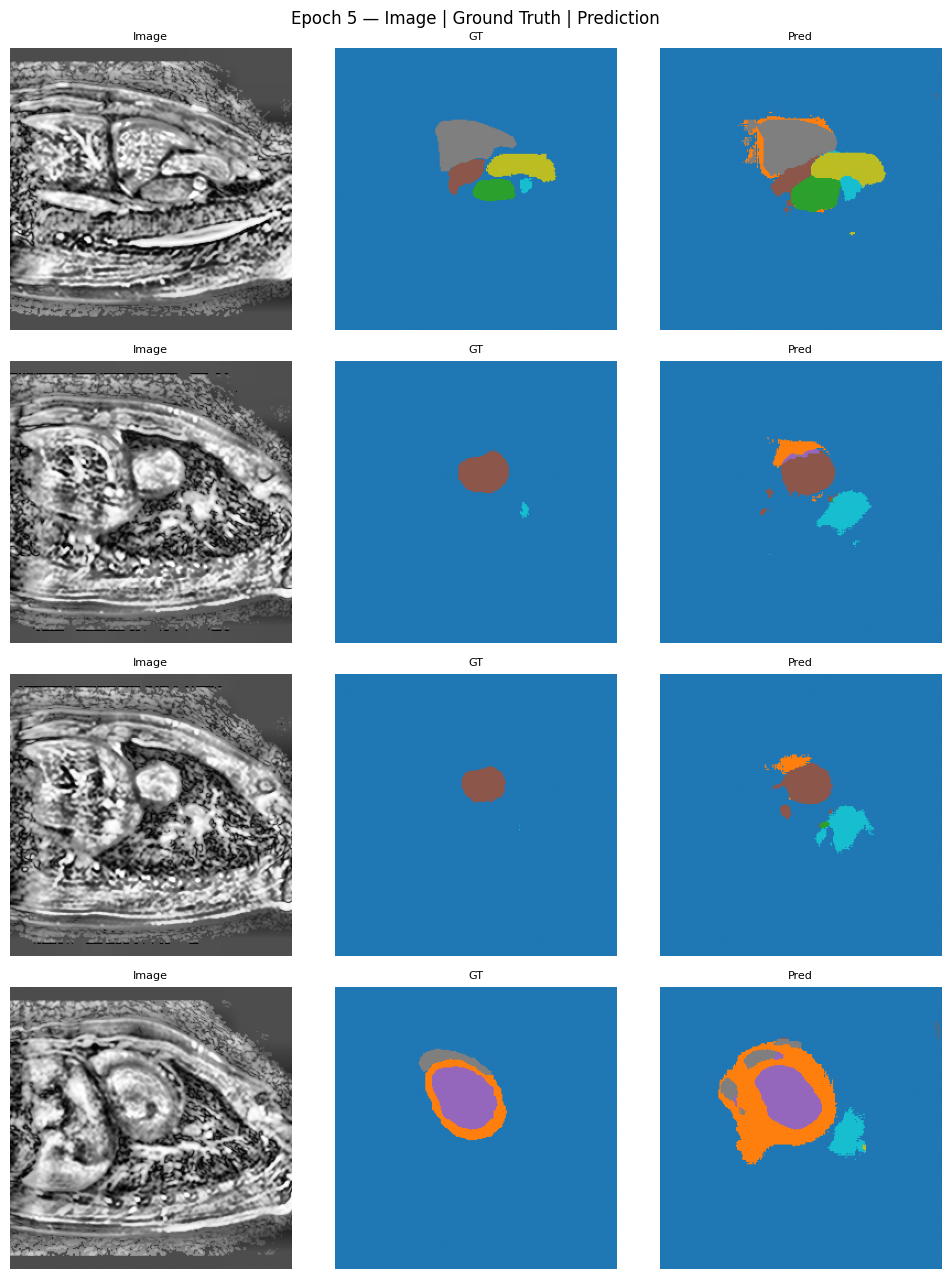


  Epoch 5 — Dice:
    MYO : 0.4939
    LA  : 0.5295
    LV  : 0.8285
    RA  : 0.6456
    RV  : 0.7251
    AA  : 0.4964
    PA  : 0.3688
    Mean: 0.5840

Epoch   6/30  train=0.5470  val=0.5759  lr=1.00e-04  patience=0
Epoch   7/30  train=0.4918  val=0.5298  lr=1.00e-04  patience=0
Epoch   8/30  train=0.4590  val=0.4916  lr=1.00e-04  patience=0
Epoch   9/30  train=0.4315  val=0.4967  lr=1.00e-04  patience=1
Epoch  10/30  train=0.4268  val=0.4865  lr=1.00e-04  patience=0


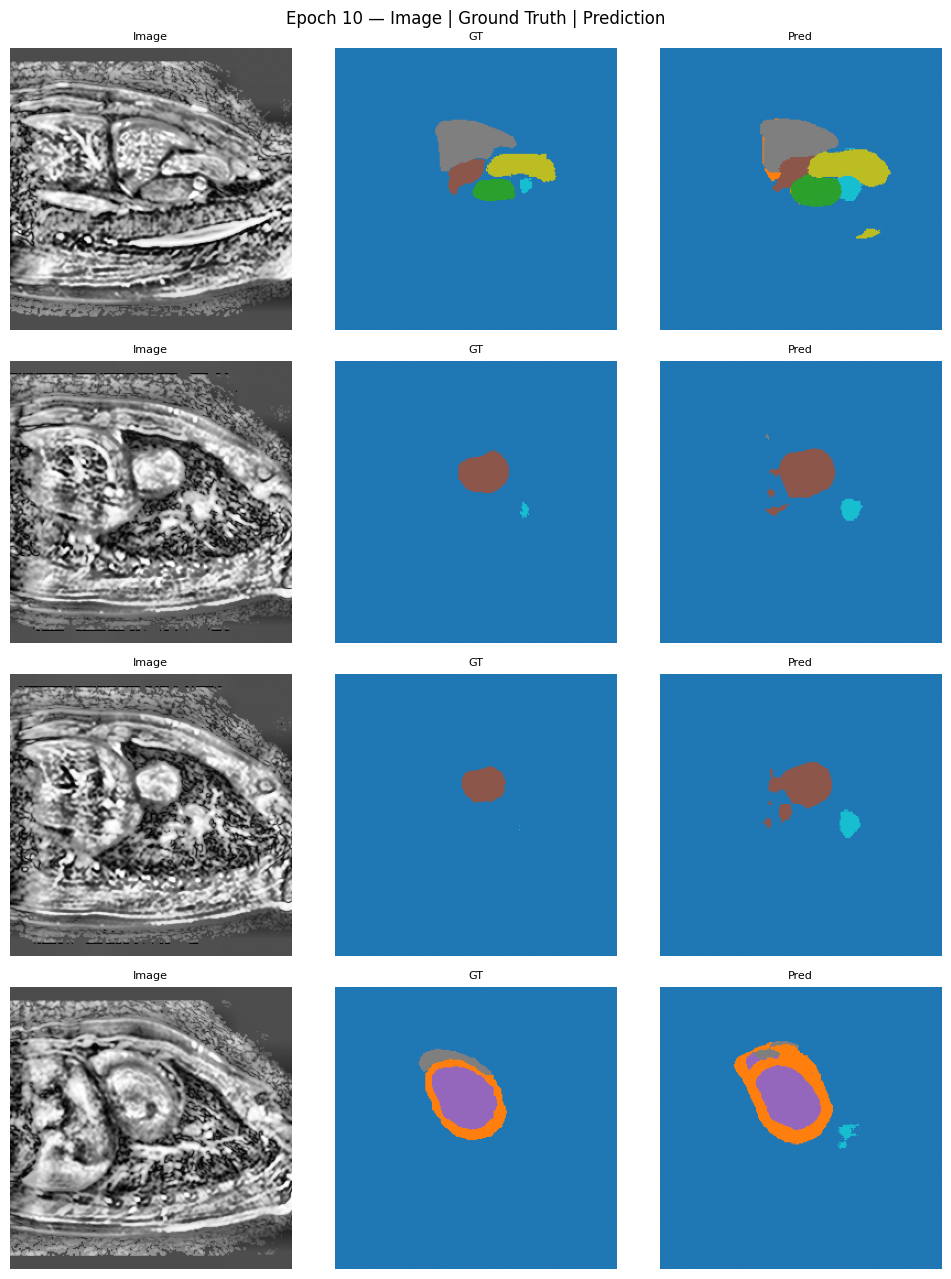


  Epoch 10 — Dice:
    MYO : 0.6872
    LA  : 0.6633
    LV  : 0.8771
    RA  : 0.7119
    RV  : 0.7275
    AA  : 0.5665
    PA  : 0.5036
    Mean: 0.6767

Epoch  11/30  train=0.4038  val=0.4392  lr=1.00e-04  patience=0
Epoch  12/30  train=0.3900  val=0.4576  lr=1.00e-04  patience=1
Epoch  13/30  train=0.3887  val=0.4509  lr=1.00e-04  patience=2
Epoch  14/30  train=0.3623  val=0.4752  lr=1.00e-04  patience=3
Epoch  15/30  train=0.3597  val=0.4502  lr=1.00e-04  patience=4


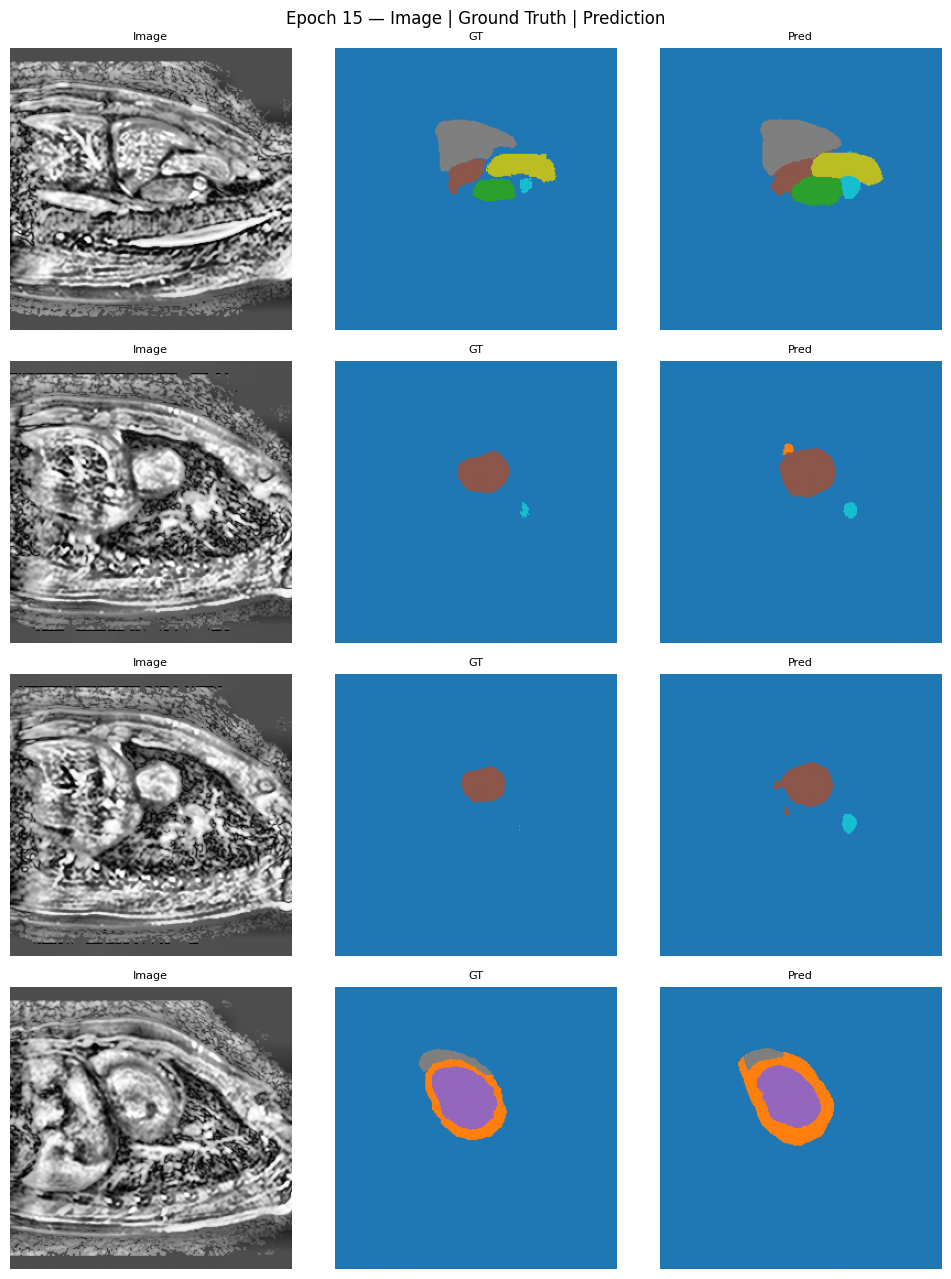


  Epoch 15 — Dice:
    MYO : 0.7429
    LA  : 0.6649
    LV  : 0.8777
    RA  : 0.7483
    RV  : 0.7710
    AA  : 0.6411
    PA  : 0.5512
    Mean: 0.7139

Epoch  16/30  train=0.3526  val=0.4886  lr=1.00e-04  patience=5
Epoch  17/30  train=0.3494  val=0.5109  lr=5.00e-05  patience=6
Epoch  18/30  train=0.3354  val=0.5359  lr=5.00e-05  patience=7
Epoch  19/30  train=0.3298  val=0.5348  lr=5.00e-05  patience=8
Epoch  20/30  train=0.3227  val=0.5643  lr=5.00e-05  patience=9


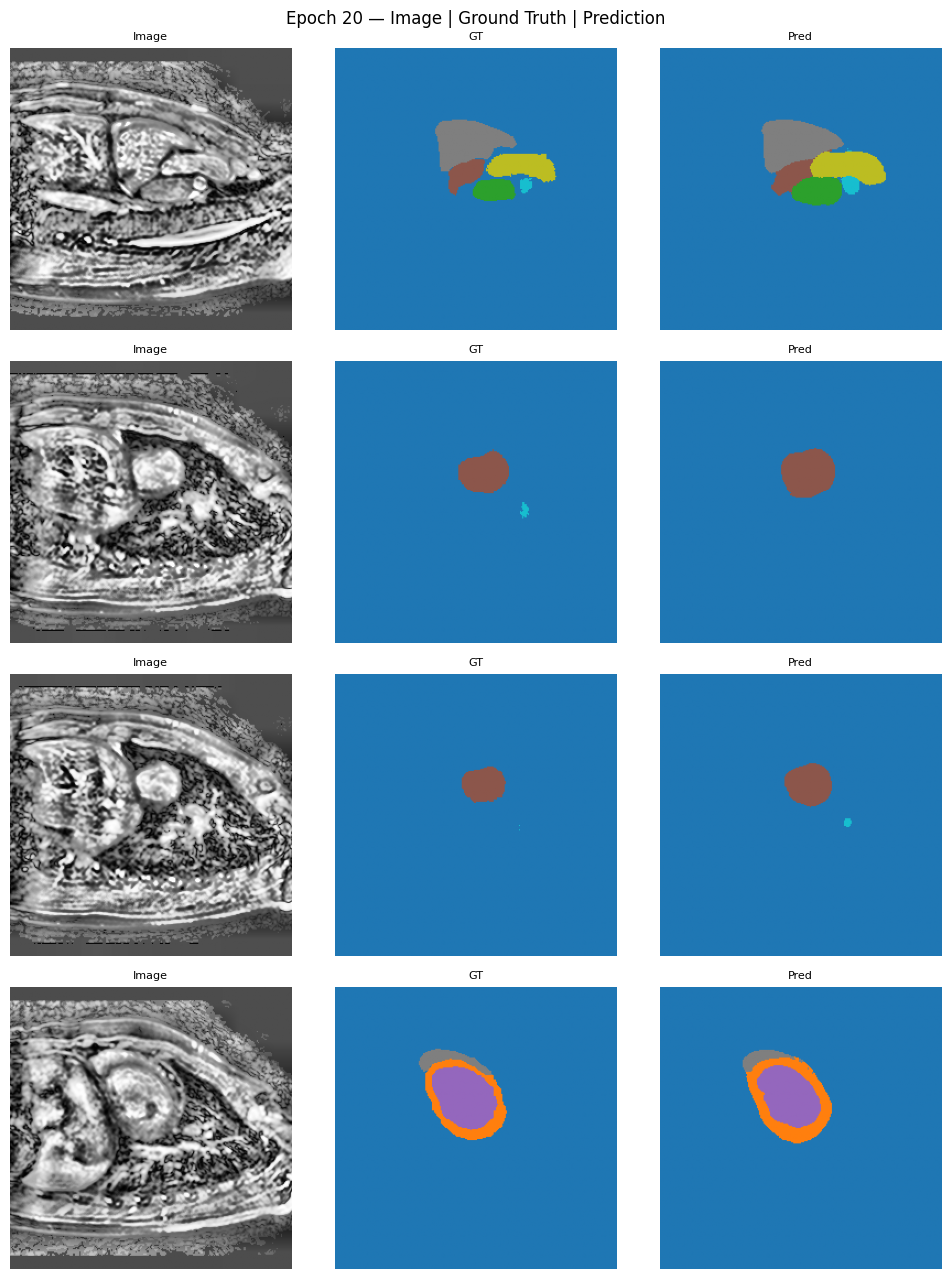


  Epoch 20 — Dice:
    MYO : 0.8193
    LA  : 0.6916
    LV  : 0.8734
    RA  : 0.7567
    RV  : 0.7936
    AA  : 0.6528
    PA  : 0.5797
    Mean: 0.7381

Epoch  21/30  train=0.3226  val=0.5710  lr=5.00e-05  patience=10
Early stopping at epoch 21
Checkpoint saved to /content/drive/MyDrive/Medical Imaging Project/checkpoints/best_resunet_mr_2026-03-31.pth


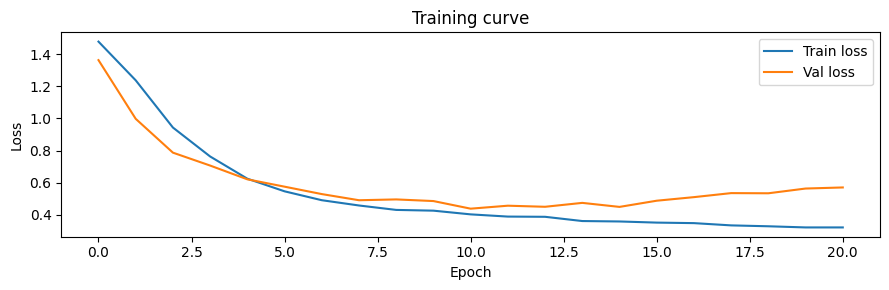

In [7]:
#  Training 
import shutil

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=5, factor=0.5
)

PREVIEW_IDXS  = random.sample(range(len(test_ds)), 4)
PREVIEW_EVERY = 5

def preview(epoch):
    model.eval()
    fig, axes = plt.subplots(4, 3, figsize=(10, 13))
    fig.suptitle(f'Epoch {epoch} - Image | Ground Truth | Prediction', fontsize=12)
    with torch.no_grad():
        for i, idx in enumerate(PREVIEW_IDXS):
            img_t, lbl_t = test_ds[idx]
            pred = model(img_t.unsqueeze(0).to(DEVICE)).argmax(dim=1).cpu().numpy()[0]
            img  = img_t.numpy()[0]
            lbl  = lbl_t.numpy()
            axes[i,0].imshow(img,  cmap='gray');                          axes[i,0].set_title('Image', fontsize=8); axes[i,0].axis('off')
            axes[i,1].imshow(lbl,  cmap='tab10', vmin=0, vmax=7);        axes[i,1].set_title('GT',    fontsize=8); axes[i,1].axis('off')
            axes[i,2].imshow(pred, cmap='tab10', vmin=0, vmax=7);        axes[i,2].set_title('Pred',  fontsize=8); axes[i,2].axis('off')
    plt.tight_layout(); plt.show()

    dice_scores = {c: [] for c in range(1, NUM_CLASSES)}
    with torch.no_grad():
        for idx in range(len(test_ds)):
            img_t, lbl_t = test_ds[idx]
            pred = model(img_t.unsqueeze(0).to(DEVICE)).argmax(dim=1).cpu().numpy()[0]
            lbl  = lbl_t.numpy()
            for c in range(1, NUM_CLASSES):
                gt_c, pred_c = lbl == c, pred == c
                if gt_c.sum() == 0: continue
                inter = (pred_c & gt_c).sum()
                denom = pred_c.sum() + gt_c.sum()
                if denom > 0: dice_scores[c].append(2 * inter / denom)
    print(f'\n  Epoch {epoch} - Dice:')
    mean_dice = []
    for c in range(1, NUM_CLASSES):
        d = np.nanmean(dice_scores[c]) if dice_scores[c] else float('nan')
        mean_dice.append(d)
        print(f'    {CLASS_NAMES[c]:<4}: {d:.4f}')
    print(f'    Mean: {np.nanmean(mean_dice):.4f}\n')


def run_epoch(loader, training):
    model.train() if training else model.eval()
    total_loss = 0
    with torch.set_grad_enabled(training):
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            loss = criterion(model(images), labels)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item()
    return total_loss / len(loader)


best_val_loss    = float('inf')
patience_counter = 0
train_losses, val_losses = [], []

for epoch in range(1, QUICK_EPOCHS + 1):
    train_loss = run_epoch(train_loader, training=True)
    val_loss   = run_epoch(val_loader,   training=False)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), CKPT_NAME)
    else:
        patience_counter += 1

    lr_now = optimizer.param_groups[0]['lr']
    print(f'Epoch {epoch:3d}/{QUICK_EPOCHS}  train={train_loss:.4f}  val={val_loss:.4f}  lr={lr_now:.2e}  patience={patience_counter}')

    if epoch % PREVIEW_EVERY == 0:
        preview(epoch)

    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f'Early stopping at epoch {epoch}')
        break

ckpt_dir = os.path.join(PROJECT_ROOT, 'checkpoints')
os.makedirs(ckpt_dir, exist_ok=True)
shutil.copy(CKPT_NAME, os.path.join(ckpt_dir, CKPT_NAME))
print(f'Checkpoint saved to {ckpt_dir}/{CKPT_NAME}')

plt.figure(figsize=(9, 3))
plt.plot(train_losses, label='Train loss')
plt.plot(val_losses,   label='Val loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('Training curve'); plt.legend()
plt.tight_layout(); plt.show()

In [9]:
#  Evaluation 
# Dice, Jaccard, Average Surface Distance (ASD), Hausdorff Distance (HD)

ckpt_path = os.path.join(PROJECT_ROOT, 'checkpoints', CKPT_NAME)
model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
model.eval()

FOREGROUND = list(range(1, NUM_CLASSES))
results = {c: {'dice': [], 'jaccard': [], 'asd': [], 'hd': []} for c in FOREGROUND}

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Evaluating'):
        preds = model(images.to(DEVICE)).argmax(dim=1).cpu().numpy()[0]
        gt    = labels.numpy()[0]
        for c in FOREGROUND:
            pred_c, gt_c = preds == c, gt == c
            if gt_c.sum() == 0: continue
            results[c]['dice'].append(dice_binary(pred_c, gt_c))
            results[c]['jaccard'].append(jaccard(pred_c, gt_c))
            asd, hd = surface_distances(pred_c, gt_c)
            results[c]['asd'].append(asd)
            results[c]['hd'].append(hd)

print(f"\n{'Class':<6} {'Dice':>7} {'Jaccard':>9} {'ASD':>8} {'HD':>8}")
print('-' * 42)
all_dice, all_jac, all_asd, all_hd = [], [], [], []
for c in FOREGROUND:
    d = np.nanmean(results[c]['dice'])
    j = np.nanmean(results[c]['jaccard'])
    a = np.nanmean(results[c]['asd'])
    h = np.nanmean(results[c]['hd'])
    all_dice.append(d); all_jac.append(j)
    all_asd.append(a);  all_hd.append(h)
    print(f"{CLASS_NAMES[c]:<6} {d:>7.4f} {j:>9.4f} {a:>8.3f} {h:>8.3f}")
print('-' * 42)
print(f"{'Mean':<6} {np.nanmean(all_dice):>7.4f} {np.nanmean(all_jac):>9.4f} "
      f"{np.nanmean(all_asd):>8.3f} {np.nanmean(all_hd):>8.3f}")

Evaluating: 100%|██████████| 236/236 [00:12<00:00, 19.22it/s]


Class     Dice   Jaccard      ASD       HD
------------------------------------------
MYO     0.7676    0.6291    2.633   14.195
LA      0.6558    0.5358    3.288    8.769
LV      0.8821    0.8183    1.285    5.183
RA      0.6506    0.5109    5.955   21.375
RV      0.7630    0.6615    3.229   13.494
AA      0.6443    0.5205    4.600   15.335
PA      0.5388    0.3882    5.807   20.926
------------------------------------------
Mean    0.7003    0.5806    3.828   14.182


In [10]:
#  Evaluation including Background (Class 0)
ALL_CLASSES = list(range(NUM_CLASSES))
results_all = {c: {'dice': [], 'jaccard': [], 'asd': [], 'hd': []} for c in ALL_CLASSES}

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc='Evaluating (all classes)'):
        preds = model(images.to(DEVICE)).argmax(dim=1).cpu().numpy()[0]
        gt    = labels.numpy()[0]
        for c in ALL_CLASSES:
            pred_c, gt_c = preds == c, gt == c
            if gt_c.sum() == 0: continue
            results_all[c]['dice'].append(dice_binary(pred_c, gt_c))
            results_all[c]['jaccard'].append(jaccard(pred_c, gt_c))
            asd, hd = surface_distances(pred_c, gt_c)
            results_all[c]['asd'].append(asd)
            results_all[c]['hd'].append(hd)

print(f"\n{'Class':<6} {'Dice':>7} {'Jaccard':>9} {'ASD':>8} {'HD':>8}")
print('-' * 42)
all_dice, all_jac, all_asd, all_hd = [], [], [], []
for c in ALL_CLASSES:
    d = np.nanmean(results_all[c]['dice'])
    j = np.nanmean(results_all[c]['jaccard'])
    a = np.nanmean(results_all[c]['asd'])
    h = np.nanmean(results_all[c]['hd'])
    all_dice.append(d); all_jac.append(j)
    all_asd.append(a);  all_hd.append(h)
    print(f"{CLASS_NAMES[c]:<6} {d:>7.4f} {j:>9.4f} {a:>8.3f} {h:>8.3f}")
print('-' * 42)
print(f"{'Mean':<6} {np.nanmean(all_dice):>7.4f} {np.nanmean(all_jac):>9.4f} "
      f"{np.nanmean(all_asd):>8.3f} {np.nanmean(all_hd):>8.3f}")


Evaluating (all classes): 100%|██████████| 236/236 [00:14<00:00, 16.32it/s]


Class     Dice   Jaccard      ASD       HD
------------------------------------------
BG      0.9895    0.9793    1.156   22.077
MYO     0.7676    0.6291    2.633   14.195
LA      0.6558    0.5358    3.288    8.769
LV      0.8821    0.8183    1.285    5.183
RA      0.6506    0.5109    5.955   21.375
RV      0.7630    0.6615    3.229   13.494
AA      0.6443    0.5205    4.600   15.335
PA      0.5388    0.3882    5.807   20.926
------------------------------------------
Mean    0.7365    0.6305    3.494   15.169
